# TTN Structure Analysis — Trained Heston Model

What does the **hierarchical** TTN give us that an MPS chain does not?

This notebook loads the trained `ttn_heston.jld2` checkpoint and extracts
structural diagnostics at every **internal tree node**:

| Quantity | Meaning |
|----------|---------|
| **`S_lr`** | Von Neumann entropy across the **left \| right** child cut at `B_h` — how strongly the two subtrees are coupled at this layer |
| **`S_up`** | Entropy across the **(left ⊗ right) \| parent** upward bond |
| **Leaf groups** | Which physical time steps sit in each subtree (tree partition, not calendar order) |

We compare with MPS **time-ordered** bipartite entropies from `mps_heston.jld2`
when available.

In [2]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using JLD2
using Random, Statistics, LinearAlgebra, Printf
using Plots

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`


## 1. Load trained checkpoints

In [3]:
bundle_dir = @__DIR__
ttn_path   = joinpath(bundle_dir, "ttn_heston.jld2")
mps_path   = joinpath(bundle_dir, "mps_heston.jld2")

isfile(ttn_path) || error("Missing $ttn_path — run ttn_training.ipynb §8 first.")
@load ttn_path ttn ttn_meta

enc = BasisEncoder(ttn_meta["m"])
enc.Smin = ttn_meta["Smin"]
enc.Smax = ttn_meta["Smax"]
M = ttn_meta["M"]
d = site_dim(enc)
logd = log(d)

has_mps = isfile(mps_path)
if has_mps
    mps, _, _, mps_meta = load_mps_bundle(mps_path)
    println("MPS loaded: M=", mps_meta["M"], "  m=", mps_meta["m"])
end

println("TTN: n_sites=", ttn.n_sites, "  N_pad=", ttn.N_pad,
        "  D_max=", ttn.D_max, "  d=", d)

MPS loaded: M=10  m=5
TTN: n_sites=8  N_pad=8  D_max=64  d=16


## 2. Visualise the tree

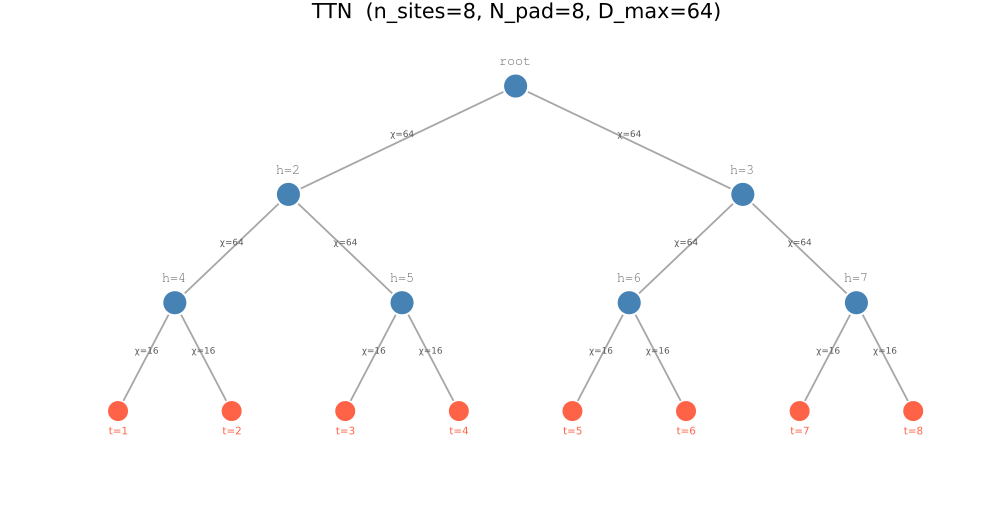

GKS: could not find font bold.ttf


In [4]:
function plot_ttn_structure(ttn::BinaryTTN; title_str=nothing, figsize=(1000, 520))
    N_pad   = ttn.N_pad
    D       = Int(round(log2(N_pad)))
    title_str === nothing &&
        (title_str = "TTN  (n_sites=$(ttn.n_sites), N_pad=$N_pad, D_max=$(ttn.D_max))")
    pos = Dict{Int, NTuple{2,Float64}}()
    for j in 1:N_pad
        pos[N_pad + j - 1] = ((j - 0.5) / N_pad, 0.0)
    end
    for d in (D - 1):-1:0
        for h in 2^d:2^(d + 1) - 1
            xl, xr = pos[2h][1], pos[2h + 1][1]
            pos[h] = ((xl + xr) / 2, (D - d) / D)
        end
    end
    p = plot(title=title_str, size=figsize, legend=false, framestyle=:none,
             xlims=(-0.02, 1.02), ylims=(-0.25, 1.18), grid=false)
    for h in 1:(N_pad - 1)
        xp, yp = pos[h]
        B = ttn.internals[h]
        for (hc, χ) in ((2h, size(B, 1)), (2h + 1, size(B, 2)))
            xc, yc = pos[hc]
            plot!(p, [xp, xc], [yp, yc], color=:gray65, lw=1.8, label=nothing)
            mx, my = (xp + xc) / 2, (yp + yc) / 2
            annotate!(p, mx, my + 0.02, text("χ=$χ", 6, :gray35))
        end
    end
    for h in 1:(N_pad - 1)
        x, y = pos[h]
        scatter!(p, [x], [y], markersize=14, markercolor=:steelblue,
                 markerstrokecolor=:white, markerstrokewidth=2)
        annotate!(p, x, y + 0.075, text(h == 1 ? "root" : "h=$h", 7, :steelblue, :bold))
    end
    for j in 1:ttn.n_sites
        h = N_pad + j - 1
        x, y = pos[h]
        scatter!(p, [x], [y], markersize=12, markercolor=:tomato,
                 markerstrokecolor=:white, markerstrokewidth=1.5)
        annotate!(p, x, y - 0.06, text("t=$j", 7, :tomato, :center))
    end
    return p
end

display(plot_ttn_structure(ttn))

## 3. Internal-cut entropies

At each blue internal node `B_h`, we SVD the tensor along two cuts:

1. **Left | Right** (`S_lr`): couples the two child subtrees.
2. **Merged | Parent** (`S_up`): couples the merged children to the upward bond.

In [5]:
cuts = ttn_internal_cuts(ttn)

@printf "%-4s %-5s %-6s %-6s %-6s %12s %12s  %s | %s\n" "h" "depth" "χ_l" "χ_r" "χ_u" "S_lr" "S_up" "leaves_left" "leaves_right"
for c in cuts
    @printf "%-4d %-5d %-6d %-6d %-6d %12.4f %12.4f  " c.h c.depth c.χ_l c.χ_r c.χ_u c.S_lr c.S_up
    println("$(c.leaves_left) | $(c.leaves_right)")
end

h    depth χ_l    χ_r    χ_u            S_lr         S_up  leaves_left | leaves_right
1    0     64     64     1            2.8616      -0.0000  [1, 2, 3, 4] | [5, 6, 7, 8]
2    1     64     64     64           3.7433       4.1589  [1, 2] | [3, 4]
3    1     64     64     64           3.8671       4.1589  [5, 6] | [7, 8]
4    2     16     16     64           2.7107       4.1589  [1] | [2]
5    2     16     16     64           2.7090       4.1589  [3] | [4]
6    2     16     16     64           2.7015       4.1589  [5] | [6]
7    2     16     16     64           2.7087       4.1589  [7] | [8]


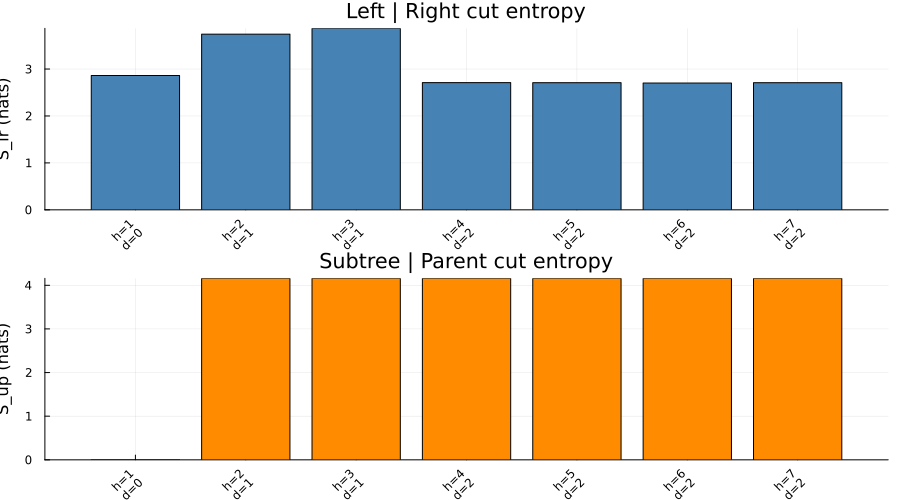

In [6]:
labels = ["h=$(c.h)\nd=$(c.depth)" for c in cuts]
p1 = bar(labels, [c.S_lr for c in cuts], ylabel="S_lr (nats)", title="Left | Right cut entropy",
         legend=false, xrotation=45, color=:steelblue)
p2 = bar(labels, [c.S_up for c in cuts], ylabel="S_up (nats)", title="Subtree | Parent cut entropy",
         legend=false, xrotation=45, color=:darkorange)
plot(p1, p2, layout=(2, 1), size=(900, 500))

## 4. Entropy by tree layer (depth)

Depth 0 = root, depth 1 = first merge, …, depth log₂(M) = adjacent-leaf pairs.

depth 0  (1 nodes):  mean S_lr = 2.8616   mean S_up = -0.0000
depth 1  (2 nodes):  mean S_lr = 3.8052   mean S_up = 4.1589
depth 2  (4 nodes):  mean S_lr = 2.7075   mean S_up = 4.1589


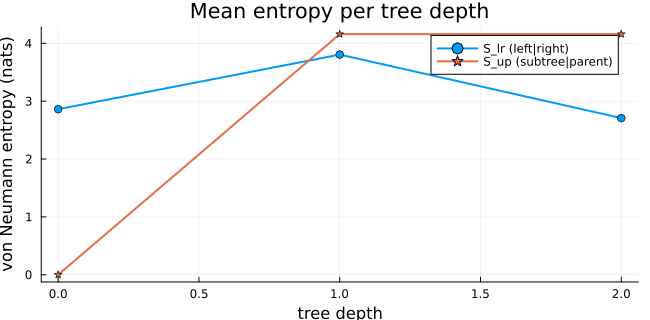

In [7]:
depths, mean_S_lr, mean_S_up, n_nodes = ttn_layer_entropy_summary(cuts)

for i in eachindex(depths)
    @printf "depth %d  (%d nodes):  mean S_lr = %.4f   mean S_up = %.4f\n" depths[i] n_nodes[i] mean_S_lr[i] mean_S_up[i]
end

p_layer = plot(title="Mean entropy per tree depth", legend=:topright, size=(650, 320))
plot!(p_layer, depths, mean_S_lr, marker=:o, lw=2, label="S_lr (left|right)")
plot!(p_layer, depths, mean_S_up, marker=:s, lw=2, label="S_up (subtree|parent)")
xlabel!(p_layer, "tree depth"); ylabel!(p_layer, "von Neumann entropy (nats)")
display(p_layer)

## 5. Which time steps does each cut separate?

Unlike an MPS (cut between `t` and `t+1`), TTN cuts group **dyadic blocks**
of leaves.  At the root, sites `1:4` are entangled with `5:8` (for `M=8`).

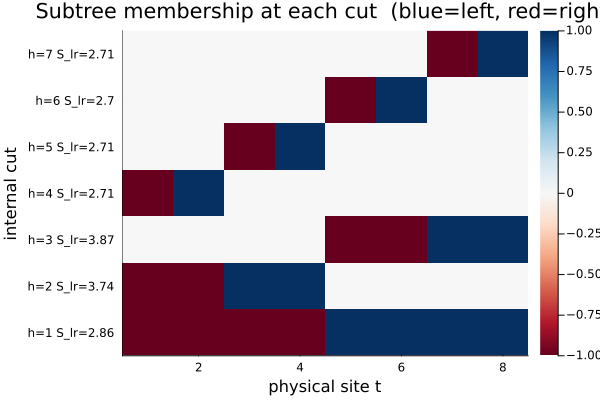

In [8]:
n_cuts = length(cuts)
mat = zeros(n_cuts, M)
for (i, c) in enumerate(cuts)
    for t in c.leaves_left;  mat[i, t] = -1.0; end   # left subtree
    for t in c.leaves_right; mat[i, t] =  1.0; end   # right subtree
end
ylabels = ["h=$(c.h) S_lr=$(round(c.S_lr,digits=2))" for c in cuts]
heatmap(mat, xlabel="physical site t", ylabel="internal cut",
        title="Subtree membership at each cut  (blue=left, red=right)",
        yticks=(1:n_cuts, ylabels), color=:RdBu, clims=(-1, 1))

## 6. Schmidt spectra at selected cuts

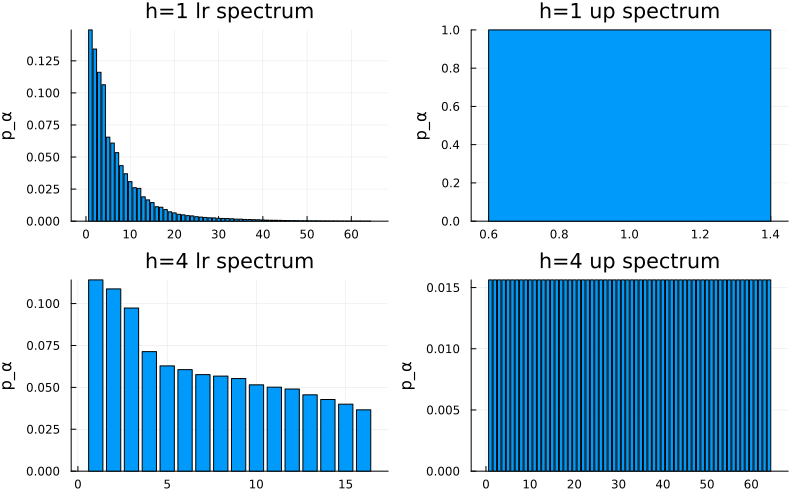

In [9]:
function plot_sv(c::TTNInternalCut; which=:lr)
    sv = which === :lr ? c.sv_lr : c.sv_up
    p  = sum(abs2, sv)
    probs = p > 0 ? abs2.(sv) ./ p : sv
    bar(1:length(probs), probs, label=nothing, ylabel="p_α", title="h=$(c.h) $(which) spectrum")
end

root = cuts[1]
mid  = cuts[cld(length(cuts), 2)]
plot(plot_sv(root; which=:lr), plot_sv(root; which=:up),
     plot_sv(mid; which=:lr),  plot_sv(mid; which=:up),
     layout=(2, 2), size=(800, 500))

## 7. Comparison with MPS time-ordered cuts

MPS bipartite entropy at bond `b` separates sites `1:b` from `b+1:M` (causal / Markov chain).
TTN `S_lr` at the root separates the **first half** of the tree from the **second half** — same
dyadic split for `M` a power of 2, but intermediate cuts are **not** contiguous in time.

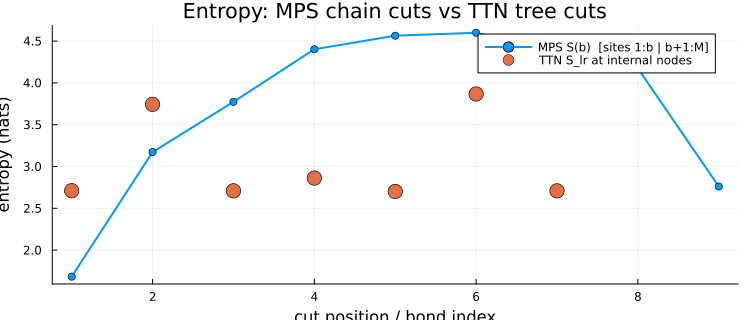


MPS final bipartite entropies (nats):
  bond  1  S =   1.6826   S_norm = 0.607
  bond  2  S =   3.1731   S_norm = 0.572
  bond  3  S =   3.7735   S_norm = 0.454
  bond  4  S =   4.4025   S_norm = 0.397
  bond  5  S =   4.5646   S_norm = 0.329
  bond  6  S =   4.5997   S_norm = 0.276
  bond  7  S =   4.3862   S_norm = 0.226
  bond  8  S =   4.1733   S_norm = 0.188
  bond  9  S =   2.7609   S_norm = 0.111


In [10]:
if has_mps
    left_canonicalize_mps!(mps)
    _, Svn_mps = bipartite_entropies(mps)
    M_mps = length(Svn_mps)

    # Map TTN cuts to closest time-ordered analogue for root / leaf-pair levels
    ttn_root = cuts[1]
    ttn_leafpairs = [c for c in cuts if length(c.leaves_left) == 1]

    p_cmp = plot(title="Entropy: MPS chain cuts vs TTN tree cuts", legend=:topright, size=(750, 320))
    plot!(p_cmp, 1:M_mps, Svn_mps, lw=2, marker=:circle, label="MPS S(b)  [sites 1:b | b+1:M]")

    # Overlay TTN S_lr at nodes whose right leaf is the cut point
    ttn_b = [last(c.leaves_left) for c in cuts if !isempty(c.leaves_left)]
    ttn_s = [c.S_lr for c in cuts if !isempty(c.leaves_left)]
    scatter!(p_cmp, ttn_b, ttn_s, ms=8, label="TTN S_lr at internal nodes")
    xlabel!(p_cmp, "cut position / bond index"); ylabel!(p_cmp, "entropy (nats)")
    display(p_cmp)

    println("\nMPS final bipartite entropies (nats):")
    for b in 1:M_mps
        normb = Svn_mps[b] / (b * logd)
        @printf "  bond %2d  S = %8.4f   S_norm = %.3f\n" b Svn_mps[b] normb
    end
else
    println("mps_heston.jld2 not found — skip MPS comparison.")
end

## 8. Bond dimensions vs entropy

Do high-χ bonds carry more entanglement?

In [11]:
χ_eff = [min(c.χ_l, c.χ_r) for c in cuts]
scatter(χ_eff, [c.S_lr for c in cuts], xlabel="min(χ_l, χ_r)", ylabel="S_lr",
        title="Bond dimension vs left|right entropy", legend=false)
for c in cuts
    annotate!(c.χ_l, c.S_lr, text("h=$(c.h)", 7))
end

## 9. Discussion

**What the hierarchy reveals**

- **Dyadic partitions**: each internal node entangles a *block* of early tree leaves
  with a *block* of late tree leaves.  Only the root cut (and perfect-binary edge
  cases) aligns with "first half / second half" of time indices.
- **`S_lr` vs `S_up`**: large `S_lr` means the model uses the bond dimension to
  correlate the two subtrees; `S_up` tracks how much information is pushed toward
  the root.
- **Depth profile**: entropy often peaks at intermediate depths where many paths
  are still being merged — analogous to area-law growth in MPS middle bonds.

**Connection to sampling pathology**

High marginal fit + low lag-1 correlation in TTN samples suggests the model stores
global bucket statistics in **wide tree cuts** (large `S_lr` at coarse layers) but
does not factorise **nearest-neighbour** dependence, which in a tree requires
correlations along non-adjacent leaf paths.  MPS chain cuts directly address
time-neighbour entanglement at every bond.

**Caveat**: these entropies are from the **amplitude tensor** in root-canonical
form, not data-averaged entanglement.  They characterise the *learned state*, not
conditional sampling trajectories.